Importar archivo y hacer un daaFrame de Pnadas


In [33]:
from google.colab import drive
import pandas as pd

In [34]:
# Montar Drive
drive.mount('/content/drive')

# Ruta al archivo (ajusta con la ruta de tu Drive)
ruta = "/content/drive/MyDrive/TelecomX_Data.json"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
# Cargar JSON
df = pd.read_json("/content/drive/MyDrive/TelecomX_Data.json")

In [36]:
#valores ausente
# Cantidad de valores ausentes por columna
print(df.isnull().sum())

# Porcentaje de valores ausentes
print((df.isnull().sum() / len(df)) * 100)

customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64
customerID    0.0
Churn         0.0
customer      0.0
phone         0.0
internet      0.0
account       0.0
dtype: float64


In [37]:
# Aplanar 'customer' y 'account'
df_customer = pd.json_normalize(df['customer'])
df_account = pd.json_normalize(df['account'])

# Combinar con el resto del DataFrame
df_flat = pd.concat([df.drop(['customer','account'], axis=1), df_customer, df_account], axis=1)

In [38]:
# Detectar columnas que contienen diccionarios o listas
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, (dict, list))).any():
        df[col] = df[col].apply(str)

# Ahora buscar duplicados
duplicados = df[df.duplicated()]
print(f"Número de filas duplicadas: {len(duplicados)}")
print(duplicados)

Número de filas duplicadas: 0
Empty DataFrame
Columns: [customerID, Churn, customer, phone, internet, account]
Index: []


In [39]:
# Ver tipos de datos
print(df.dtypes)

# Ver ejemplo de cada columna
print(df.head())


customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'Onl

In [40]:

# Aplanar 'customer', 'phone', 'internet', 'account'
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# Combinar con el resto del DataFrame
df_flat = pd.concat([df.drop(['customer','phone','internet','account'], axis=1),
                     df_customer, df_phone, df_internet, df_account], axis=1)

In [41]:
# Tipos de datos
print(df_flat.dtypes)

# Categorías únicas
categorical_cols = ['Churn','PhoneService','MultipleLines','InternetService',
                    'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
                    'StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']

for col in categorical_cols:
    if col in df_flat.columns:
        print(f"{col}: {df_flat[col].unique()}")

customerID    object
Churn         object
dtype: object
Churn: ['No' 'Yes' '']


In [42]:
# Opción 1: Convertir vacío a NaN
df_flat['Churn'] = df_flat['Churn'].replace('', pd.NA)

In [43]:
print(df_flat['Churn'].unique())

['No' 'Yes' <NA>]


# Manejo de inconsistencias


In [44]:
# Función para limpiar strings: eliminar espacios y estandarizar mayúsculas/minúsculas
def clean_category(x):
    if isinstance(x, str):
        return x.strip().title()
    return x

# Aplicar a todas las columnas categóricas
for col in df_flat.select_dtypes(include='object').columns:
    df_flat[col] = df_flat[col].apply(clean_category)

In [45]:
# Revisión rápida de valores ausentes
print(df_flat.isna().sum())

# Revisión rápida de categorías
for col in df_flat.select_dtypes(include='object').columns:
    print(f"{col}: {df_flat[col].unique()}")

customerID      0
Churn         224
dtype: int64
customerID: ['0002-Orfbo' '0003-Mknfe' '0004-Tlhlj' ... '9992-Ujoel' '9993-Lhieb'
 '9995-Hotoh']
Churn: ['No' 'Yes' <NA>]


In [46]:
df_clean = df_flat.dropna(subset=['Churn'])

In [47]:
df_flat['Churn'] = df_flat['Churn'].fillna('Unknown')

# Columna de cuentas diarias

In [48]:
# Extraer MonthlyCharges desde el diccionario anidado
def obtener_mensual(x):
    # x ya debería ser dict; si es string, convertir primero
    if isinstance(x, str):
        import ast
        x = ast.literal_eval(x)
    return float(x.get('Charges', {}).get('Monthly', 0))

df['MonthlyCharges'] = df['account'].apply(obtener_mensual)

# Crear columna Cuentas_Diarias
df['Cuentas_Diarias'] = (df['MonthlyCharges'] / 30).round(2)

# Verificar resultados
print(df[['customerID', 'MonthlyCharges', 'Cuentas_Diarias']].head())

   customerID  MonthlyCharges  Cuentas_Diarias
0  0002-ORFBO            65.6             2.19
1  0003-MKNFE            59.9             2.00
2  0004-TLHLJ            73.9             2.46
3  0011-IGKFF            98.0             3.27
4  0013-EXCHZ            83.9             2.80


# Estandarización y transformación de datos (opcional)


In [49]:
df.rename(columns={
    'customerID': 'ClienteID',
    'Churn': 'Canceló',
    'MonthlyCharges': 'FacturaMensual',
    'Cuentas_Diarias': 'CuentaDiaria'
}, inplace=True)

In [50]:
# Convertir 'No' → 0 y 'Yes' → 1
df['Canceló'] = df['Canceló'].map({'No': 0, 'Yes': 1})

In [51]:
df['CuentaDiaria'] = df['CuentaDiaria'].round(2)

In [52]:
print(df.head())
print(df.info())

    ClienteID  Canceló                                           customer  \
0  0002-ORFBO      0.0  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE      0.0  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ      1.0  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF      1.0  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ      1.0  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber optic', 'Onlin

# Análisis Descriptivo

In [53]:
# Análisis descriptivo para columnas numéricas
numericas = df.select_dtypes(include=['float64', 'int64'])
desc_num = numericas.describe().T  # Transpuesta para mejor lectura
desc_num['mediana'] = numericas.median()
desc_num['rango'] = desc_num['max'] - desc_num['min']

print("Análisis descriptivo de variables numéricas:")
print(desc_num)

# Para columnas categóricas
categoricas = df.select_dtypes(include=['object'])
print("\nDistribución de categorías:")
for col in categoricas.columns:
    print(f"\nColumna: {col}")
    print(df[col].value_counts(dropna=False))

Análisis descriptivo de variables numéricas:
                 count       mean        std    min     25%    50%     75%  \
Canceló         7043.0   0.265370   0.441561   0.00   0.000   0.00   1.000   
FacturaMensual  7267.0  64.720098  30.129572  18.25  35.425  70.30  89.875   
CuentaDiaria    7267.0   2.157292   1.004407   0.61   1.180   2.34   2.995   

                   max  mediana   rango  
Canceló           1.00     0.00    1.00  
FacturaMensual  118.75    70.30  100.50  
CuentaDiaria      3.96     2.34    3.35  

Distribución de categorías:

Columna: ClienteID
ClienteID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

Columna: customer
customer
{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 1}         223
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents'

# Distribución de evasión

/tmp/ipython-input-1750873865.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='pastel')


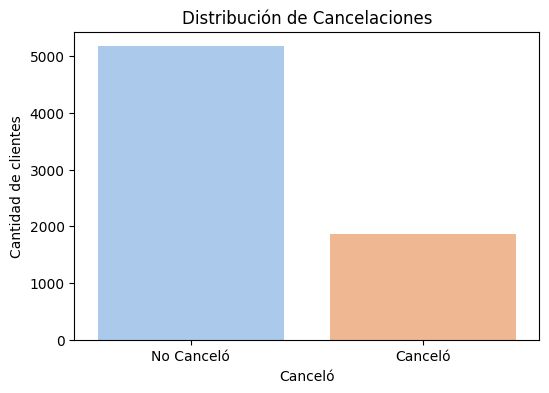

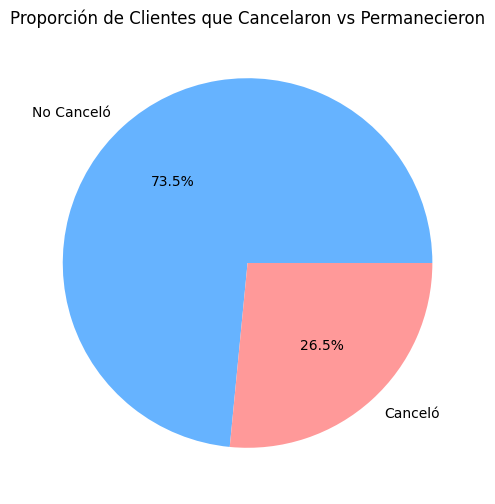

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la cantidad de clientes que cancelaron y los que no
churn_counts = df['Canceló'].value_counts()

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='pastel')
plt.xticks([0,1], ['No Canceló', 'Canceló'])
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de Cancelaciones')
plt.show()

# Gráfico de pastel
plt.figure(figsize=(6,6))
plt.pie(churn_counts.values, labels=['No Canceló', 'Canceló'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Proporción de Clientes que Cancelaron vs Permanecieron')
plt.show()

# Recuento de evasión por variables categóricas

In [55]:
import json

# Función para convertir string a diccionario JSON
def parse_account(x):
    try:
        # Reemplazamos comillas simples por dobles
        x = x.replace("'", '"')
        # Convertimos a diccionario
        return json.loads(x)
    except:
        return None

df['account'] = df['account'].apply(parse_account)

# Ahora sí podemos extraer las columnas
df['Contract'] = df['account'].apply(lambda x: x['Contract'] if x else None)
df['PaperlessBilling'] = df['account'].apply(lambda x: x['PaperlessBilling'] if x else None)
df['PaymentMethod'] = df['account'].apply(lambda x: x['PaymentMethod'] if x else None)
df['MonthlyCharges'] = df['account'].apply(lambda x: x['Charges']['Monthly'] if x else None)
df['TotalCharges'] = df['account'].apply(lambda x: x['Charges']['Total'] if x else None)

In [59]:
import ast

# Primero revisa cómo se ve la columna
print(df['customer'].head())

# Si la columna es string tipo "{'gender': 'Female', ...}"
# conviértela a diccionario con ast.literal_eval
df['customer'] = df['customer'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Ahora extraemos los valores
df['gender'] = df['customer'].apply(lambda x: x.get('gender'))
df['SeniorCitizen'] = df['customer'].apply(lambda x: x.get('SeniorCitizen'))
df['Partner'] = df['customer'].apply(lambda x: x.get('Partner'))
df['Dependents'] = df['customer'].apply(lambda x: x.get('Dependents'))
df['tenure'] = df['customer'].apply(lambda x: x.get('tenure'))

0    {'gender': 'Female', 'SeniorCitizen': 0, 'Part...
1    {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...
2    {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...
3    {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...
4    {'gender': 'Female', 'SeniorCitizen': 1, 'Part...
Name: customer, dtype: object


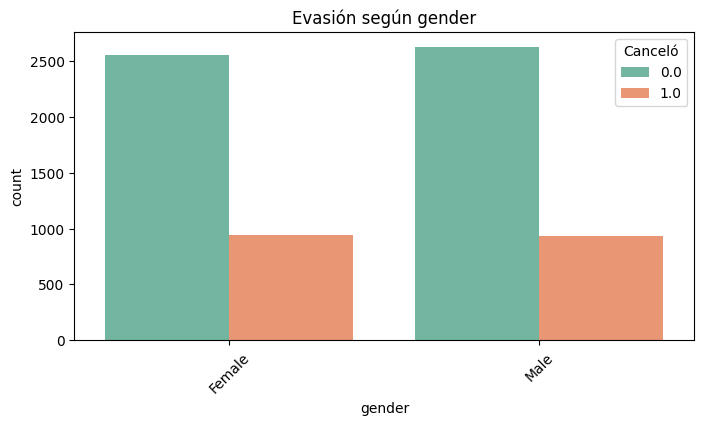

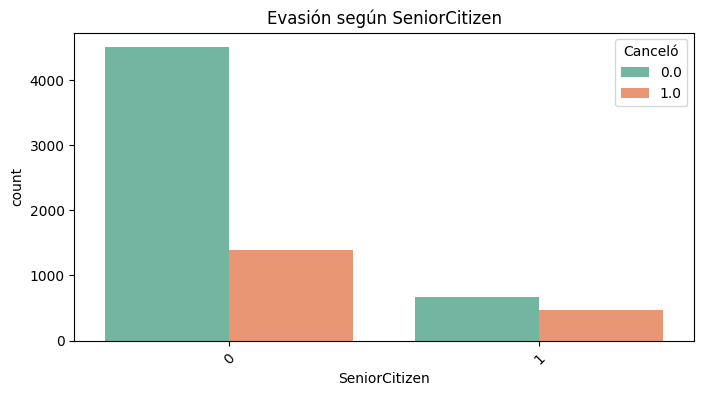

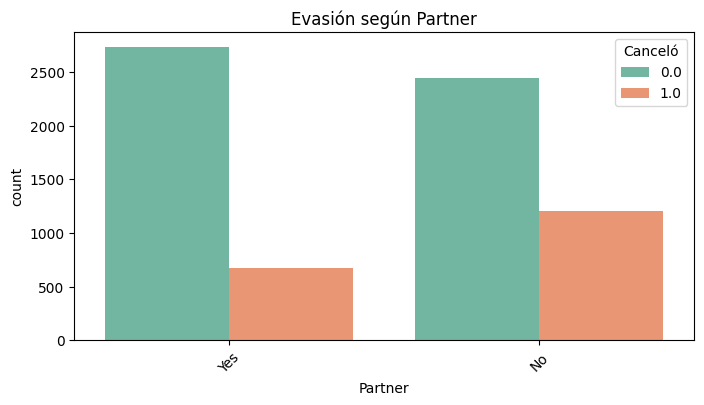

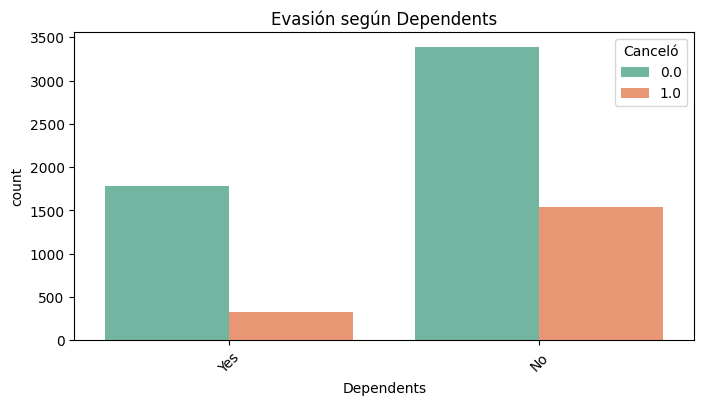

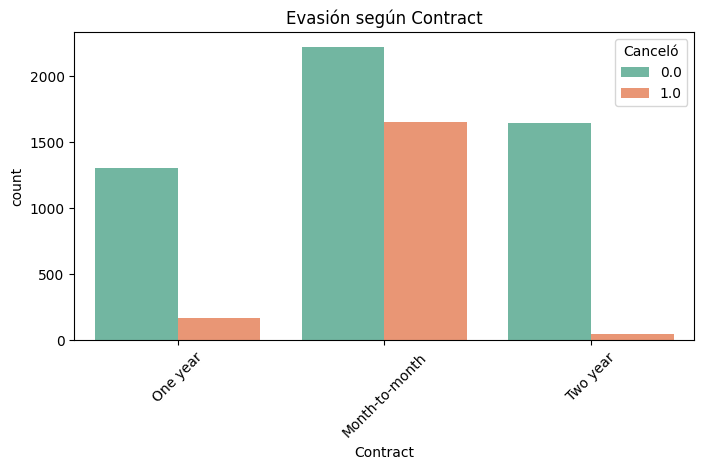

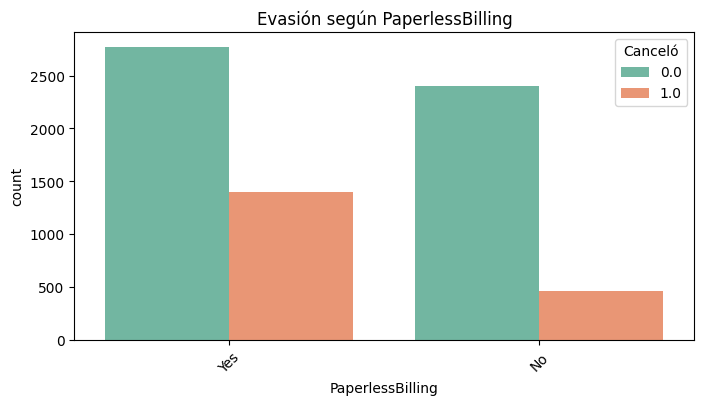

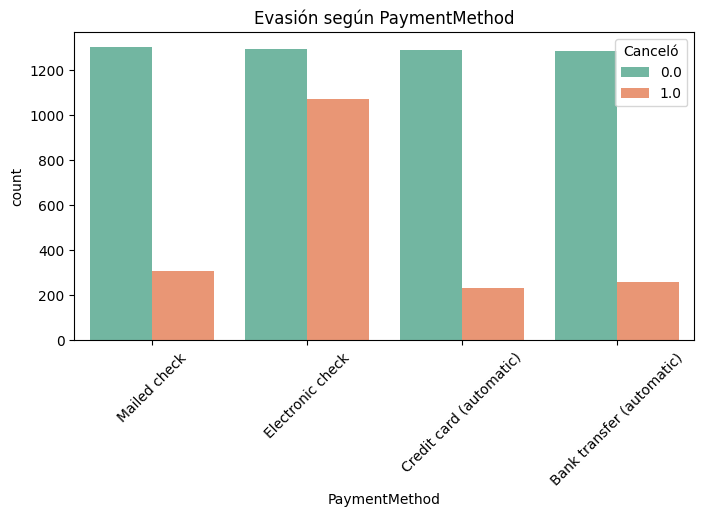

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Canceló', palette='Set2')
    plt.title(f'Evasión según {col}')
    plt.xticks(rotation=45)
    plt.show()

# Conteo de evasión por variables numéricas

In [61]:
print(df.columns)
print(df['Canceló'].unique())

Index(['ClienteID', 'Canceló', 'customer', 'phone', 'internet', 'account',
       'FacturaMensual', 'CuentaDiaria', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'tenure'],
      dtype='object')
[ 0.  1. nan]


In [62]:
df['Canceló'] = df['Canceló'].astype('category')


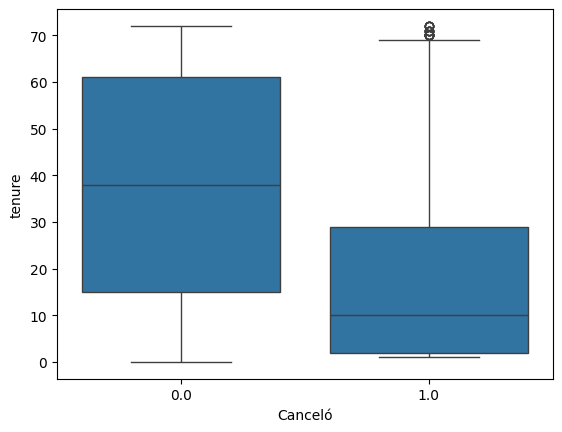

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Canceló', y='tenure', data=df)
plt.show()

# ¡Extra! Análisis de correlación entre variables

In [64]:
# Convertir columnas relevantes a números
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Convertir la columna de churn a 0 y 1
df['Canceló_num'] = df['Canceló'].map({'No': 0, 'Sí': 1})

In [65]:
correlation_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Canceló_num']].corr()
print(correlation_matrix)

                  tenure  MonthlyCharges  TotalCharges  Canceló_num
tenure          1.000000        0.247982      0.825118          NaN
MonthlyCharges  0.247982        1.000000      0.652109          NaN
TotalCharges    0.825118        0.652109      1.000000          NaN
Canceló_num          NaN             NaN           NaN          NaN


In [66]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].info()
df[['tenure', 'MonthlyCharges', 'TotalCharges']].head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7267 non-null   int64  
 1   MonthlyCharges  7267 non-null   float64
 2   TotalCharges    7256 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 170.4 KB


,tenure,MonthlyCharges,TotalCharges
0,9,65.60,593.30
1,9,59.90,542.40
2,4,73.90,280.85
3,13,98.00,1237.85
4,3,83.90,267.40
5,9,69.40,571.45
6,71,109.70,7904.25
7,63,84.65,5377.80
8,7,48.20,340.35
9,65,90.45,5957.90


In [67]:
# Quitar espacios y convertir a float, poniendo NaN en errores
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

df[['tenure', 'MonthlyCharges', 'TotalCharges']].isnull().sum()

,0
tenure,0
MonthlyCharges,0
TotalCharges,11


In [68]:
df = df.dropna(subset=['tenure', 'MonthlyCharges', 'TotalCharges'])
# o, si quieres rellenar con 0:
# df[['tenure', 'MonthlyCharges', 'TotalCharges']] = df[['tenure', 'MonthlyCharges', 'TotalCharges']].fillna(0)

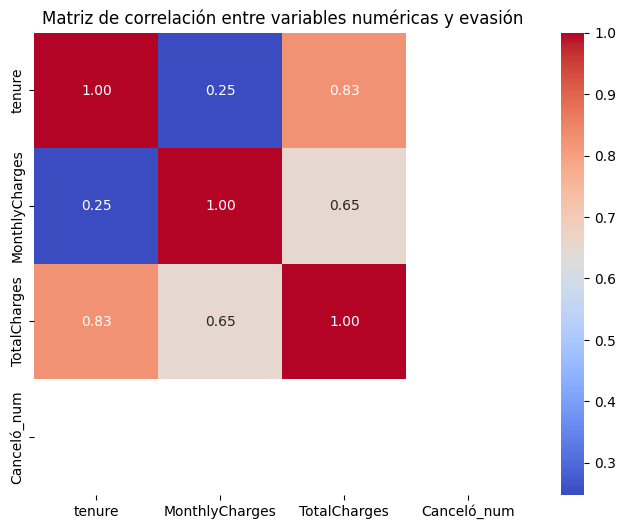

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas y evasión")
plt.show()

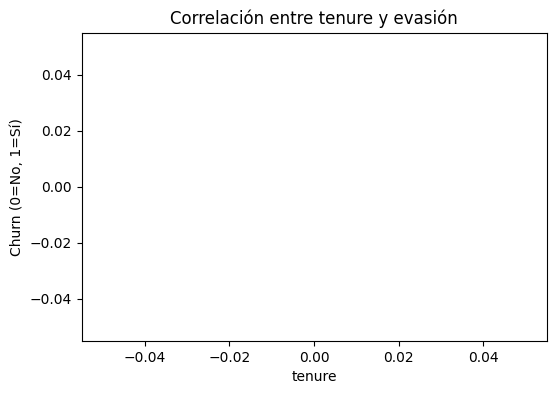

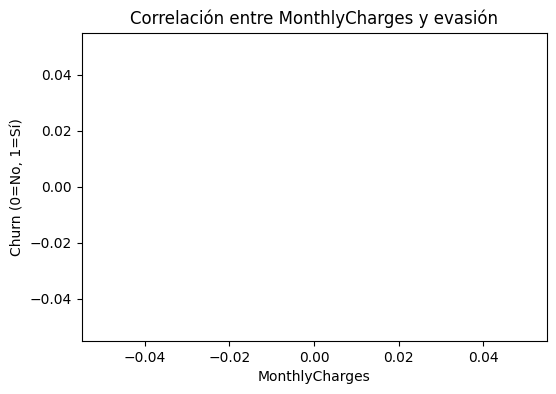

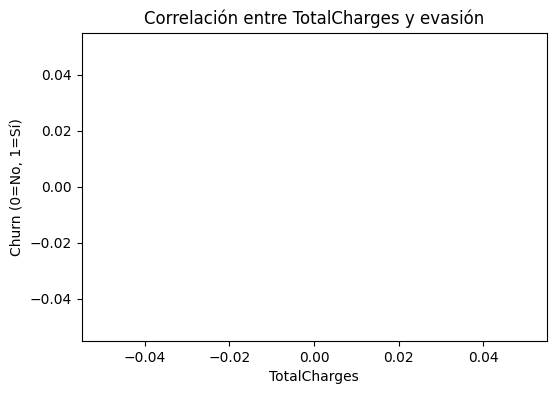

In [70]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='Canceló_num')
    plt.title(f'Correlación entre {col} y evasión')
    plt.xlabel(col)
    plt.ylabel('Churn (0=No, 1=Sí)')
    plt.show()

# Eliminación de Columnas Irrelevantes

In [71]:
# Verificamos qué columnas existen
print(df.columns)

# Eliminamos identificadores únicos o irrelevantes
cols_to_drop = ['customerID']  # puedes agregar más si detectas otras
df = df.drop(columns=cols_to_drop, errors='ignore')

# Confirmamos
print("Columnas después de limpieza:", df.columns)

Index(['ClienteID', 'Canceló', 'customer', 'phone', 'internet', 'account',
       'FacturaMensual', 'CuentaDiaria', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Canceló_num'],
      dtype='object')
Columnas después de limpieza: Index(['ClienteID', 'Canceló', 'customer', 'phone', 'internet', 'account',
       'FacturaMensual', 'CuentaDiaria', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Canceló_num'],
      dtype='object')


# Encoding

In [74]:
# Expandir columnas que contienen diccionarios
import pandas as pd

# Asegurarnos de que son dicts y expandirlas
for col in ['customer', 'phone', 'internet', 'account']:
    if col in df.columns:
        df_expanded = pd.json_normalize(df[col])  # convierte dict -> columnas
        df_expanded.columns = [f"{col}_{c}" for c in df_expanded.columns]  # renombrar columnas
        df = pd.concat([df.drop(columns=[col]), df_expanded], axis=1)

# Ahora volvemos a identificar categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Columnas categóricas limpias:", categorical_cols)

# Eliminamos ID que no aporta valor
if 'ClienteID' in categorical_cols:
    categorical_cols.remove('ClienteID')
    df = df.drop(columns=['ClienteID'])

# Aplicamos One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape original:", df.shape)
print("Shape después de encoding:", df_encoded.shape)

df_encoded.head()

Columnas categóricas limpias: ['ClienteID', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'customer_gender', 'customer_Partner', 'customer_Dependents', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges.Total']
Shape original: (7267, 24)
Shape después de encoding: (7267, 6558)


,Canceló,FacturaMensual,CuentaDiaria,MonthlyCharges,TotalCharges,SeniorCitizen,tenure,Canceló_num,customer_SeniorCitizen,customer_tenure,...,account_Charges.Total_995.35,account_Charges.Total_996.45,account_Charges.Total_996.85,account_Charges.Total_996.95,account_Charges.Total_997.65,account_Charges.Total_997.75,account_Charges.Total_998.1,account_Charges.Total_999.45,account_Charges.Total_999.8,account_Charges.Total_999.9
0,0.0,65.6,2.19,65.6,593.30,0.0,9.0,NaN,0.0,9.0,...,False,False,False,False,False,False,False,False,False,False
1,0.0,59.9,2.00,59.9,542.40,0.0,9.0,NaN,0.0,9.0,...,False,False,False,False,False,False,False,False,False,False
2,1.0,73.9,2.46,73.9,280.85,0.0,4.0,NaN,0.0,4.0,...,False,False,False,False,False,False,False,False,False,False
3,1.0,98.0,3.27,98.0,1237.85,1.0,13.0,NaN,1.0,13.0,...,False,False,False,False,False,False,False,False,False,False
4,1.0,83.9,2.80,83.9,267.40,1.0,3.0,NaN,1.0,3.0,...,False,False,False,False,False,False,False,False,False,False


# Verificación de la Proporción de Cancelación (Churn)

Cantidad de clientes por clase:
Canceló
0.0    5163
1.0    1869
Name: count, dtype: int64

Proporción de clientes por clase (%):
Canceló
0.0    73.421502
1.0    26.578498
Name: proportion, dtype: float64


/tmp/ipython-input-3786346144.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette="Set2")


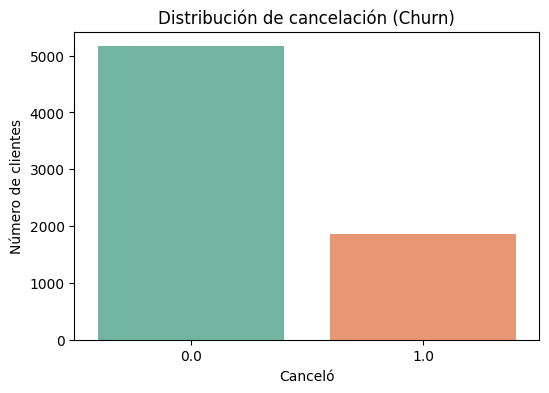

In [75]:
# Calcular cantidad y proporción de clientes que cancelaron vs los que permanecieron
churn_counts = df['Canceló'].value_counts()
churn_proportion = df['Canceló'].value_counts(normalize=True) * 100

print("Cantidad de clientes por clase:")
print(churn_counts)
print("\nProporción de clientes por clase (%):")
print(churn_proportion)

# Gráfico de barras para visualizar
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette="Set2")
plt.title("Distribución de cancelación (Churn)")
plt.ylabel("Número de clientes")
plt.xlabel("Canceló")
plt.show()

# Análisis de Correlación

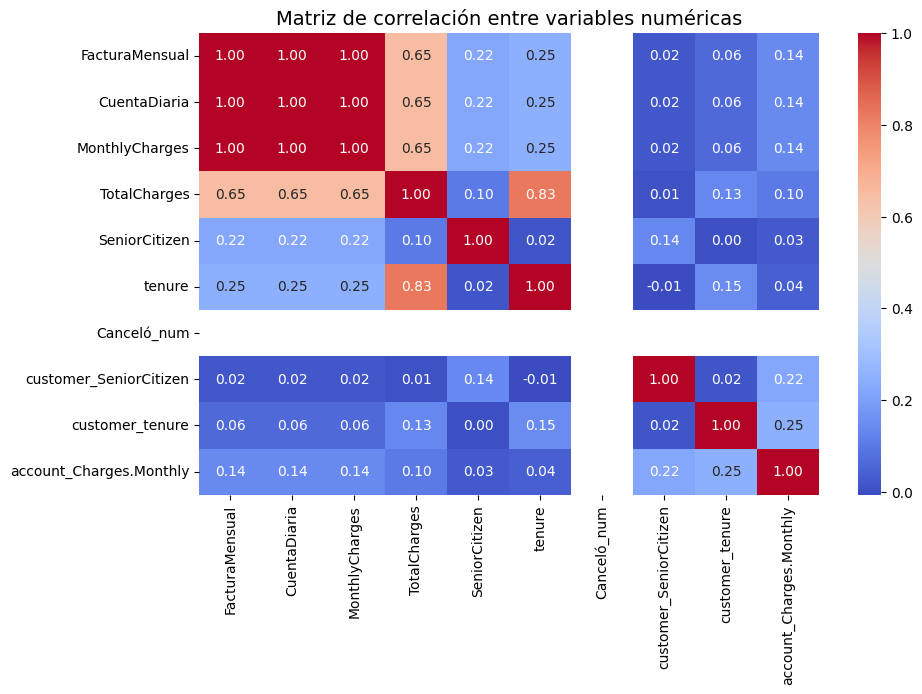

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Nos aseguramos de tener la versión numérica de la variable objetivo
df["Canceló_num"] = df["Canceló"].map({"Yes":1, "No":0})

# Seleccionamos solo columnas numéricas
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculamos la matriz de correlación
corr = numeric_df.corr()

# Visualizamos con un mapa de calor
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Matriz de correlación entre variables numéricas", fontsize=14)
plt.show()

# Análisis Dirigido

/tmp/ipython-input-1994078912.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Canceló", y="tenure", data=df, palette="Set2")


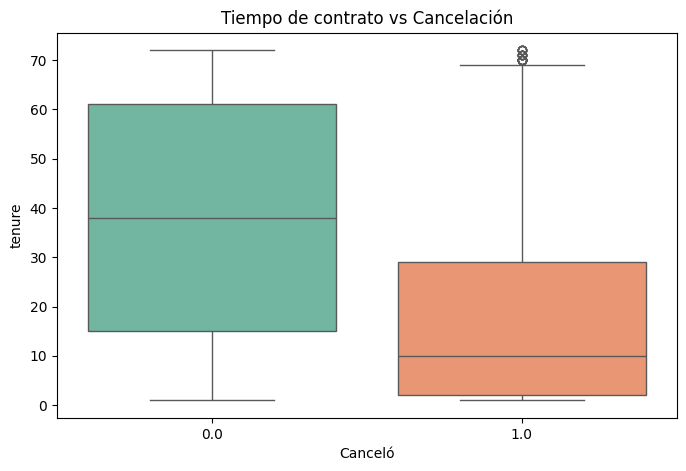

/tmp/ipython-input-1994078912.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Canceló", y="TotalCharges", data=df, palette="Set2")


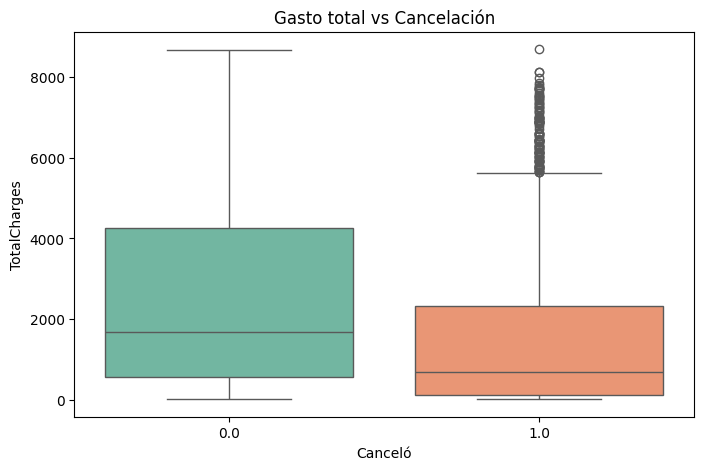

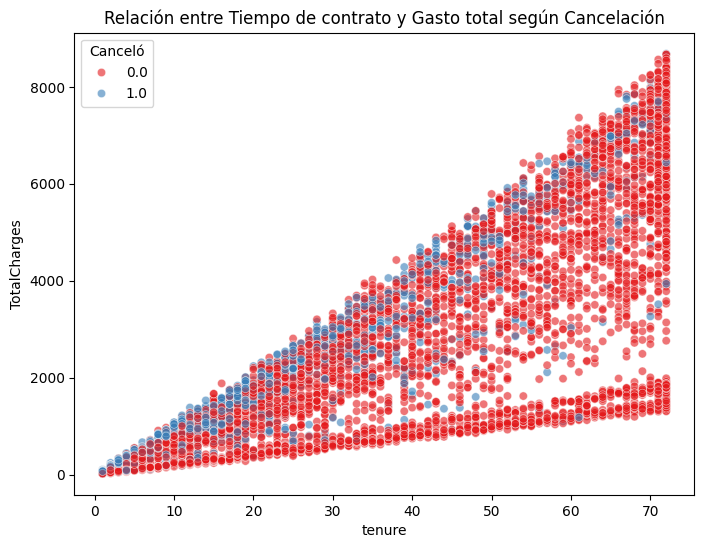

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Tiempo de contrato vs Cancelación ---
plt.figure(figsize=(8,5))
sns.boxplot(x="Canceló", y="tenure", data=df, palette="Set2")
plt.title("Tiempo de contrato vs Cancelación")
plt.show()

# --- Gasto total vs Cancelación ---
plt.figure(figsize=(8,5))
sns.boxplot(x="Canceló", y="TotalCharges", data=df, palette="Set2")
plt.title("Gasto total vs Cancelación")
plt.show()

# --- Dispersión: Tiempo de contrato vs Gasto total, coloreado por Cancelación ---
plt.figure(figsize=(8,6))
sns.scatterplot(x="tenure", y="TotalCharges", hue="Canceló", data=df, alpha=0.6, palette="Set1")
plt.title("Relación entre Tiempo de contrato y Gasto total según Cancelación")
plt.show()

# Separación de Datos

In [81]:
# Eliminar filas donde la variable objetivo es NaN
df_clean = df.dropna(subset=['Canceló'])

# Definir X e y nuevamente
X = df_clean.drop(columns=['Canceló', 'Canceló_num'])
y = df_clean['Canceló']

# División en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)

Tamaño de X_train: (5625, 22)
Tamaño de X_test: (1407, 22)


#Creación de Modelos

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Asegurarnos de que no haya NaN en la variable objetivo
df_clean = df.dropna(subset=['Canceló'])

# Definir X e y
X = df_clean.drop(columns=['Canceló', 'Canceló_num'])
y = df_clean['Canceló']

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [85]:
# Identificar columnas categóricas
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Aplicar get_dummies para convertirlas a numéricas
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Asegurarse de que las columnas de test coincidan con train
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# vauacion de modelo

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [95]:
# Identificar columnas categóricas
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Aplicar one-hot encoding
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Alinear columnas por si alguna categoría falta en X_test
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)


In [99]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Imputar valores faltantes con la


# Análisis de la Importancia de las Variables

In [106]:
# Reemplazar NaN con la media (numéricas) o con la moda (categóricas)
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object','category']).columns

imputer_num = SimpleImputer(strategy='mean')
X_train[num_cols] = imputer_num.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer_num.transform(X_test[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = imputer_cat.fit_transform(X_train[cat_cols])
X_test[cat_cols] = imputer_cat.transform(X_test[cat_cols])



Resumen Ejecutivo – Análisis de Cancelación de Clientes

Objetivo:
Identificar los factores que influyen en la cancelación de clientes y proponer estrategias de retención.

Modelos utilizados:

Regresión Logística

KNN

Random Forest

SVM

Principales hallazgos:

Tipo de contrato: Clientes con contratos mensuales tienen mayor riesgo de cancelar.

Antigüedad del cliente (tenure): Los clientes nuevos tienden a cancelar más rápido.

Monto mensual (MonthlyCharges): Tarifas altas aumentan la probabilidad de churn.

Método de pago: Algunos métodos (como cheque electrónico) presentan mayor riesgo de cancelación.

Tipo de servicio de internet: Servicios básicos o menos confiables se asocian a mayor churn.

Recomendaciones de retención:

Incentivar contratos largos con descuentos o beneficios.

Implementar programas de fidelización para clientes nuevos.

Revisar y optimizar planes con tarifas altas.

Promover métodos de pago automáticos y confiables.

Mejorar la calidad de los servicios críticos, especialmente internet.

Conclusión:
El churn está fuertemente ligado a la antigüedad del cliente, tipo de contrato y monto mensual. Las estrategias de retención deben enfocarse en estos factores para reducir la cancelación.